In [1]:
import matplotlib.pyplot as plt
import numpy as np

from scipy import special


import time

import sys
import os

from datetime import datetime
import subprocess

from os.path import exists

import read_config_utils as cu

import matplotlib as mpl

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:



#---- all with exactly 10k events in each fake data sample

#-- perfect
#input_dir = 'bootstrap-toy-study8b-6d-1d'

#-- good
#input_dir = 'bootstrap-toy-study8b-6d-1f'

#-- nominal
#input_dir = 'bootstrap-toy-study8b-6d-1c'

#-- medium bad
#input_dir = 'bootstrap-toy-study8b-6d-1e'

#-- very bad
#input_dir = 'bootstrap-toy-study8b-6d-1g'






#-- nominal
#input_dir = 'bootstrap-toy-study8b-1d-2a-total-fluctuations'

#input_dir = 'bootstrap-toy-study8b-2d-2a-total-fluctuations'

#input_dir = 'bootstrap-toy-study8b-4d-2a-total-fluctuations'

#input_dir = 'bootstrap-toy-study8b-6d-2a-total-fluctuations'



#-----

#input_dir = 'hist-pdf-toy-study-1d-1a-perfect'

#input_dir = 'hist-pdf-toy-study-1d-1a-nominal-resolution'


#-------



#input_dir = 'hist-pdf-toy-study-1d-3c-nominal-resolution'

#input_dir = 'hist-pdf-toy-study-1d-3c-perfect'

#input_dir = 'hist-pdf-toy-study-1d-3c-mediumbad'

#input_dir = 'hist-pdf-toy-study-1d-3c-goodres'




#input_dir = 'bootstrap-toy-study8a-1d-1d-nominal-resolution'

#input_dir = 'bootstrap-toy-study8a-1d-1d-perfect'




#input_dir = 'bootstrap-toy-study8a-1d-2a-perfect'

#input_dir = 'bootstrap-toy-study8a-1d-2a-nominal-resolution'

#input_dir = 'bootstrap-toy-study8a-1d-2a-mediumbad'



feature_index = 0




#input_dir = 'bootstrap-toy-study9a-1d-1a-total-fluctuations-softplus-nominal'

#input_dir = 'bootstrap-toy-study9a-1d-1a-total-fluctuations-softplus-perfect'

#input_dir = 'bootstrap-toy-study9a-1d-1b-total-fluctuations'




#input_dir = 'bootstrap-toy-study9b-1d-1a-total-fluctuations'

#input_dir = 'bootstrap-toy-study9b-1d-1b-total-fluctuations'

#input_dir = 'hist-pdf-toy-study-1d-4a'






#input_dir = 'bootstrap-toy-study9b-1d-1c-total-fluctuations'

#input_dir = 'bootstrap-toy-study9b-1d-1d-total-fluctuations'

#input_dir = 'hist-pdf-toy-study-1d-4b'





#input_dir = 'bootstrap-toy-study9b-1d-1g-total-fluctuations'

#input_dir = 'bootstrap-toy-study9b-1d-1h-total-fluctuations'

#input_dir = 'hist-pdf-toy-study-1d-4d'



#input_dir = 'bootstrap-toy-study9b-1d-3a-total-fluctuations'

#input_dir = 'bootstrap-toy-study9b-1d-1b-total-fluctuations'

#input_dir = 'bootstrap-toy-study9b-1d-3b-total-fluctuations'

#input_dir = 'bootstrap-toy-study9b-1d-3c-total-fluctuations'






#input_dir = 'bootstrap-all-in-one-inspect-of-1d-1a'

#input_dir = 'bootstrap-all-in-one-inspect-of-1d-1b'







#input_dir = 'bootstrap-all-in-one-inspect-of-1d-4a'



input_dir = 'bootstrap-ensemble-1d-1d'




hist_nbins = 120
#hist_xlow = -3.2
#hist_xhigh = 4.8

hist_xlow = -4.0
hist_xhigh = 4.0



with open( '%s/train-and-true-samples.npy' % input_dir, 'rb') as f :
    train_pts = np.load(f)
    train_det_pts = np.load(f)
    true_pts = np.load(f)
    true_det_pts = np.load(f)
    
print('\n\n')
print(' shape of train_pts:  %s' % str(train_pts.shape))
print(' shape of true_pts:   %s' % str(true_pts.shape))
print('\n\n')






 shape of train_pts:  (100000, 1)
 shape of true_pts:   (10000, 1)





In [3]:
hist_bin_width = (hist_xhigh - hist_xlow)/hist_nbins

hist_bin_centers = np.linspace( hist_xlow + hist_bin_width/2, hist_xhigh - hist_bin_width/2, hist_nbins)

In [4]:
config_file = '%s/config.txt' % (input_dir)

if not exists(config_file) :
    
    print("\n\n\n ******* Input file does not exist: %s\n\n\n" % config_file )
    sys.exit()
    

In [5]:
ndim = int(cu.get_par( config_file, "ndim"))
print("\n\n Number of feature dimensions: %d\n\n" % ndim)
ngen_true = int(cu.get_par( config_file, "ngen_true"))
print(' ngen_true = %d\n' % ngen_true )



 Number of feature dimensions: 1


 ngen_true = 10000



In [6]:
#with open( '%s/config-pars.npy' % input_dir, 'rb') as f :
#    train_mu = np.load(f, allow_pickle=True )
#    train_rho = np.load(f, allow_pickle=True)
#    train_sig = np.load(f, allow_pickle=True)    
#    true_mu = np.load(f, allow_pickle=True )
#    true_rho = np.load(f, allow_pickle=True)
#    true_sig = np.load(f, allow_pickle=True)  
#    resolution = np.load(f, allow_pickle=True)

In [7]:
#import pickle
#with open( '%s/config-pars.pkl' % input_dir, 'rb') as f :
#    train_mu = pickle.load(f)
#    train_rho = pickle.load(f)
#    train_sig = pickle.load(f)
#    true_mu = pickle.load(f)
#    true_rho = pickle.load(f)
#    true_sig = pickle.load(f)
#    resolution = pickle.load(f)
#    train_cov = pickle.load(f)
#    true_cov = pickle.load(f)

In [8]:
n_samples = 0

for fi in range(5000) :
    
    fname = '%s/bootstrap-weights-%03d.npy' % (input_dir, fi)
    
    if exists(fname) :
        n_samples = n_samples + 1
        
print("\n\n Found %d bootstrap samples.\n\n" % n_samples )



 Found 100 bootstrap samples.




In [9]:
boot_hist_content = np.zeros( shape=(n_samples, hist_nbins))




for bi in range(n_samples) :
    
        

    fname = '%s/bootstrap-weights-%03d.npy' % (input_dir, bi)

    if not exists(fname) :  
        print('\n\n *** Missing %s' % fname )
        continue

    with open(fname,'rb') as f :            

        final_push_weights_scaled = np.load(f)
        print(' boot %3d weights: ' % bi, end='')
        print( final_push_weights_scaled)

        hist_content,_ = np.histogram( train_pts[:,feature_index], bins=hist_nbins, weights=final_push_weights_scaled, range=[hist_xlow, hist_xhigh] )
        #print(hist_content)
        boot_hist_content[bi,:] = hist_content



    

 boot   0 weights: [0.11692017 0.09087988 0.09384429 ... 0.11191043 0.11828705 0.08586433]
 boot   1 weights: [0.11772959 0.08913832 0.09234319 ... 0.11387493 0.12147803 0.08379307]
 boot   2 weights: [0.11723034 0.08488259 0.08759029 ... 0.10983302 0.11719273 0.08081624]
 boot   3 weights: [0.12114448 0.0873775  0.09047911 ... 0.11030901 0.11838532 0.08223609]
 boot   4 weights: [0.11222706 0.08937353 0.09198326 ... 0.10959594 0.11663721 0.08490459]
 boot   5 weights: [0.10987755 0.08483171 0.08772663 ... 0.1117553  0.11912725 0.08043296]
 boot   6 weights: [0.11323041 0.09369908 0.09697288 ... 0.11540325 0.11914758 0.0884132 ]
 boot   7 weights: [0.11091148 0.0902774  0.09272815 ... 0.10776115 0.11366936 0.08597512]
 boot   8 weights: [0.12044627 0.08993888 0.09269474 ... 0.11201346 0.11772629 0.0855592 ]
 boot   9 weights: [0.11088984 0.08835181 0.09113089 ... 0.10927937 0.11526092 0.08379651]
 boot  10 weights: [0.11423412 0.08784253 0.09119706 ... 0.10858796 0.11253087 0.08217432]

<function matplotlib.pyplot.show(close=None, block=None)>

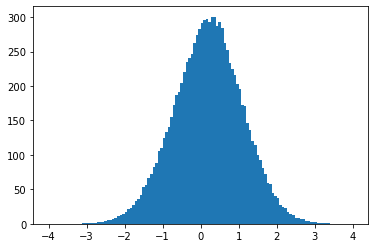

In [10]:
plt.hist( train_pts[:,feature_index], bins=hist_nbins, weights=final_push_weights_scaled, range=[hist_xlow, hist_xhigh] )
plt.show

In [11]:
hist_corr_mat = np.zeros( shape=(hist_nbins, hist_nbins) )
hist_cov_mat = np.zeros( shape=(hist_nbins, hist_nbins) )

for bi in range(hist_nbins) :
    
    for bj in range( hist_nbins ) :
        
        ccm = np.corrcoef( np.row_stack( ((boot_hist_content[:,bi], boot_hist_content[:,bj])) ) )
        cvm =      np.cov( np.row_stack( ((boot_hist_content[:,bi], boot_hist_content[:,bj])) ) )
        
        hist_corr_mat[bi,bj] = ccm[0,1]
        
        hist_cov_mat[bi,bj] = cvm[0,1]
        
        

/home/owen/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/owen/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [12]:
hist_corr_mat[0,hist_nbins-1] = -1.

<function matplotlib.pyplot.show(close=None, block=None)>

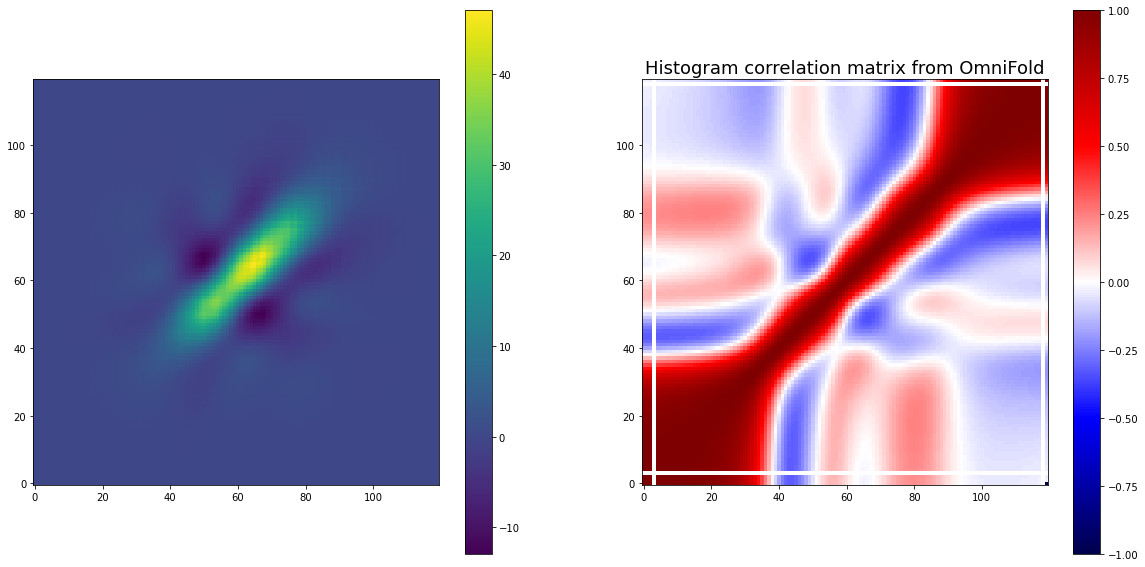

In [13]:
fig,ax = plt.subplots( 1, 2, figsize=(2*10,10))


im_covmat = ax[0].imshow(hist_cov_mat, origin='lower')
ax[0].figure.colorbar( im_covmat, ax=ax[0] )

im = ax[1].imshow(hist_corr_mat, cmap='seismic', origin='lower')
ax[1].figure.colorbar( im, ax=ax[1] )



ax[1].set_title('Histogram correlation matrix from OmniFold', fontsize=18)



plt.show

In [14]:
min_cov_element = np.min(hist_cov_mat)
max_cov_element = np.max(hist_cov_mat)
print('\n\n Min and max elements of cov mat:  %.2f , %.2f\n\n' % (min_cov_element, max_cov_element))
hist_cov_mat_copy = np.copy( hist_cov_mat )
hist_cov_mat_copy[0,hist_nbins-1] = -1. * max_cov_element



 Min and max elements of cov mat:  -12.90 , 47.02




<function matplotlib.pyplot.show(close=None, block=None)>

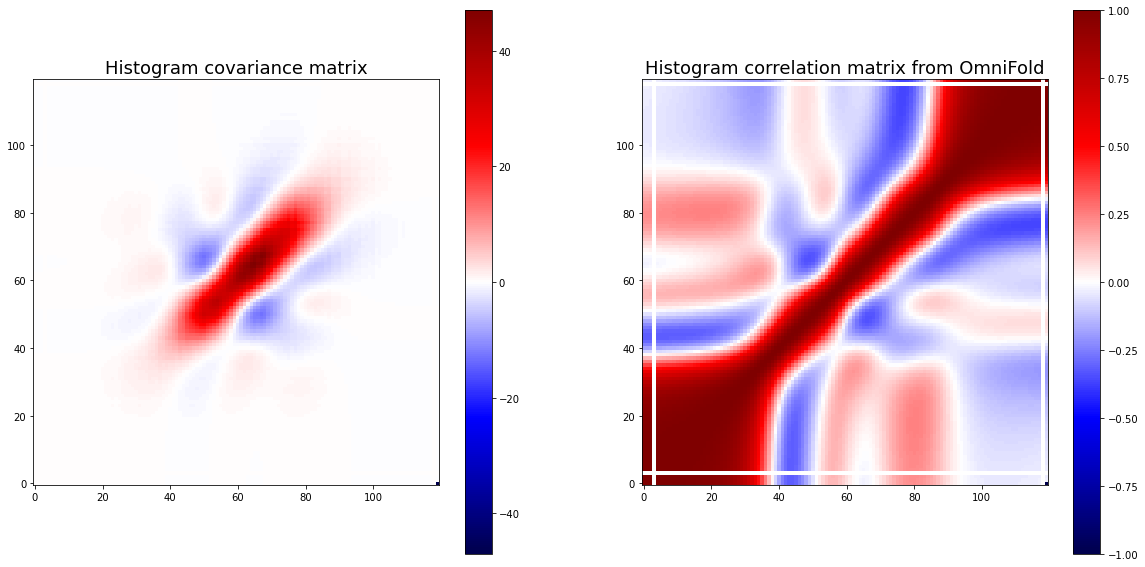

In [15]:
fig,ax = plt.subplots( 1, 2, figsize=(2*10,10))


im_covmat = ax[0].imshow(hist_cov_mat_copy, cmap='seismic', origin='lower')
ax[0].figure.colorbar( im_covmat, ax=ax[0] )

im = ax[1].imshow(hist_corr_mat, cmap='seismic', origin='lower')
ax[1].figure.colorbar( im, ax=ax[1] )


ax[0].set_title('Histogram covariance matrix', fontsize=18)

ax[1].set_title('Histogram correlation matrix from OmniFold', fontsize=18)



plt.show

In [16]:
for bi in range(hist_nbins) :
    for bj in range(hist_nbins ) :
        
        calc_corr = hist_cov_mat[bi,bj] / np.sqrt( hist_cov_mat[bi,bi] * hist_cov_mat[bj,bj])
        
        print('  %2d, %2d :  histi  %10.2f   histj %10.2f  cov = %9.3f   cor = %9.4f  (%9.4f)' % 
              (bi, bj, boot_hist_content[0,bi], boot_hist_content[0,bj],
               hist_cov_mat[bi,bj], hist_corr_mat[bi,bj], calc_corr))



   0,  0 :  histi        0.03   histj       0.03  cov =     0.000   cor =    1.0000  (   1.0000)
   0,  1 :  histi        0.03   histj       0.03  cov =     0.000   cor =    1.0000  (   1.0000)
   0,  2 :  histi        0.03   histj       0.04  cov =     0.000   cor =    0.9999  (   0.9999)
   0,  3 :  histi        0.03   histj       0.00  cov =     0.000   cor =       nan  (      nan)
   0,  4 :  histi        0.03   histj       0.08  cov =     0.000   cor =    0.9995  (   0.9995)
   0,  5 :  histi        0.03   histj       0.12  cov =     0.000   cor =    0.9991  (   0.9991)
   0,  6 :  histi        0.03   histj       0.10  cov =     0.000   cor =    0.9987  (   0.9987)
   0,  7 :  histi        0.03   histj       0.09  cov =     0.000   cor =    0.9978  (   0.9978)
   0,  8 :  histi        0.03   histj       0.24  cov =     0.000   cor =    0.9973  (   0.9973)
   0,  9 :  histi        0.03   histj       0.25  cov =     0.000   cor =    0.9963  (   0.9963)
   0, 10 :  histi        0.03 

/tmp/ipykernel_3073570/1040150517.py:4: RuntimeWarning: invalid value encountered in scalar divide
  calc_corr = hist_cov_mat[bi,bj] / np.sqrt( hist_cov_mat[bi,bi] * hist_cov_mat[bj,bj])


  32, 76 :  histi       22.47   histj     178.83  cov =     0.580   cor =    0.0917  (   0.0917)
  32, 77 :  histi       22.47   histj     177.60  cov =     0.675   cor =    0.1037  (   0.1037)
  32, 78 :  histi       22.47   histj     152.14  cov =     0.662   cor =    0.1149  (   0.1149)
  32, 79 :  histi       22.47   histj     140.74  cov =     0.691   cor =    0.1256  (   0.1256)
  32, 80 :  histi       22.47   histj     124.93  cov =     0.675   cor =    0.1343  (   0.1343)
  32, 81 :  histi       22.47   histj     117.49  cov =     0.682   cor =    0.1406  (   0.1406)
  32, 82 :  histi       22.47   histj     102.78  cov =     0.625   cor =    0.1436  (   0.1436)
  32, 83 :  histi       22.47   histj      95.16  cov =     0.590   cor =    0.1428  (   0.1428)
  32, 84 :  histi       22.47   histj      83.20  cov =     0.511   cor =    0.1376  (   0.1376)
  32, 85 :  histi       22.47   histj      73.96  cov =     0.437   cor =    0.1282  (   0.1282)
  32, 86 :  histi       22.47 

  68,  8 :  histi      290.50   histj       0.24  cov =     0.005   cor =    0.0156  (   0.0156)
  68,  9 :  histi      290.50   histj       0.25  cov =     0.006   cor =    0.0179  (   0.0179)
  68, 10 :  histi      290.50   histj       0.33  cov =     0.009   cor =    0.0202  (   0.0202)
  68, 11 :  histi      290.50   histj       0.34  cov =     0.010   cor =    0.0225  (   0.0225)
  68, 12 :  histi      290.50   histj       0.40  cov =     0.012   cor =    0.0247  (   0.0247)
  68, 13 :  histi      290.50   histj       0.65  cov =     0.021   cor =    0.0272  (   0.0272)
  68, 14 :  histi      290.50   histj       0.59  cov =     0.020   cor =    0.0297  (   0.0297)
  68, 15 :  histi      290.50   histj       0.94  cov =     0.034   cor =    0.0326  (   0.0326)
  68, 16 :  histi      290.50   histj       1.15  cov =     0.043   cor =    0.0356  (   0.0356)
  68, 17 :  histi      290.50   histj       1.51  cov =     0.059   cor =    0.0385  (   0.0385)
  68, 18 :  histi      290.50 

  105, 67 :  histi        2.39   histj     296.77  cov =    -0.313   cor =   -0.1464  (  -0.1464)
  105, 68 :  histi        2.39   histj     290.50  cov =    -0.368   cor =   -0.1749  (  -0.1749)
  105, 69 :  histi        2.39   histj     268.35  cov =    -0.407   cor =   -0.2070  (  -0.2070)
  105, 70 :  histi        2.39   histj     260.34  cov =    -0.466   cor =   -0.2413  (  -0.2413)
  105, 71 :  histi        2.39   histj     241.69  cov =    -0.501   cor =   -0.2742  (  -0.2742)
  105, 72 :  histi        2.39   histj     232.69  cov =    -0.549   cor =   -0.3043  (  -0.3043)
  105, 73 :  histi        2.39   histj     224.47  cov =    -0.589   cor =   -0.3290  (  -0.3290)
  105, 74 :  histi        2.39   histj     210.84  cov =    -0.600   cor =   -0.3454  (  -0.3454)
  105, 75 :  histi        2.39   histj     203.67  cov =    -0.613   cor =   -0.3524  (  -0.3524)
  105, 76 :  histi        2.39   histj     178.83  cov =    -0.552   cor =   -0.3489  (  -0.3489)
  105, 77 :  histi  

(-50.0, 50.0)

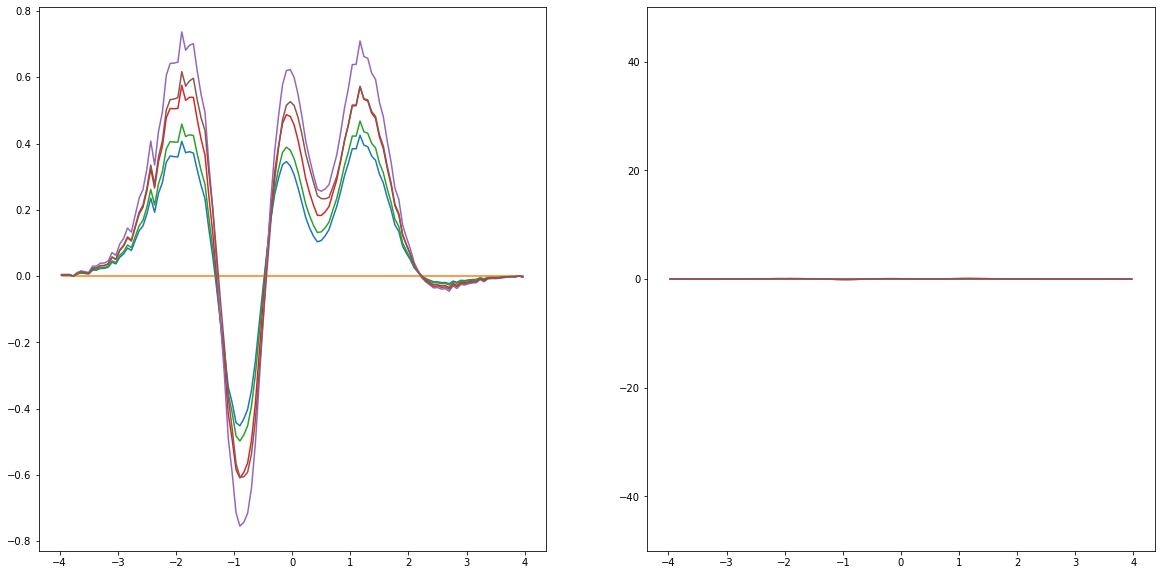

In [17]:
fig,ax = plt.subplots( 1, 2, figsize=(2*10,10))

ax[0].plot( hist_bin_centers, hist_cov_mat[20,:] )
ax[0].plot( hist_bin_centers, np.zeros(hist_nbins))
ax[0].plot( hist_bin_centers, hist_cov_mat[21,:] )
if hist_nbins >= 13 :
    ax[0].plot( hist_bin_centers, hist_cov_mat[22,:] )
    ax[0].plot( hist_bin_centers, hist_cov_mat[23,:] )
    ax[0].plot( hist_bin_centers, hist_cov_mat[24,:] )

ax[1].plot( hist_bin_centers, hist_cov_mat[8,:] )
ax[1].plot( hist_bin_centers, np.zeros(hist_nbins))
ax[1].plot( hist_bin_centers, hist_cov_mat[9,:] )
if hist_nbins >= 13 :
    ax[1].plot( hist_bin_centers, hist_cov_mat[10,:] )
    ax[1].plot( hist_bin_centers, hist_cov_mat[11,:] )
    ax[1].plot( hist_bin_centers, hist_cov_mat[12,:] )


ax[1].set_ylim([-50,50])

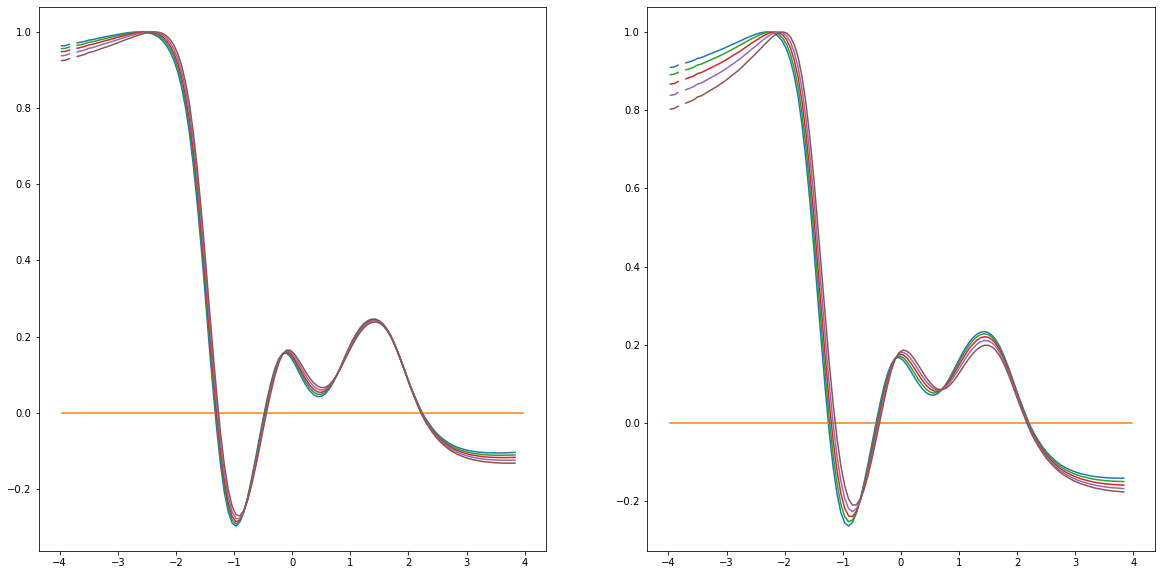

In [18]:
fig,ax = plt.subplots( 1, 2, figsize=(2*10,10))

ax[0].plot( hist_bin_centers, hist_corr_mat[20,:] )
ax[0].plot( hist_bin_centers, np.zeros(hist_nbins))
ax[0].plot( hist_bin_centers, hist_corr_mat[21,:] )
ax[0].plot( hist_bin_centers, hist_corr_mat[22,:] )
ax[0].plot( hist_bin_centers, hist_corr_mat[23,:] )
ax[0].plot( hist_bin_centers, hist_corr_mat[24,:] )


ax[1].plot( hist_bin_centers, hist_corr_mat[25,:] )
ax[1].plot( hist_bin_centers, np.zeros(hist_nbins))
ax[1].plot( hist_bin_centers, hist_corr_mat[26,:] )
ax[1].plot( hist_bin_centers, hist_corr_mat[27,:] )
ax[1].plot( hist_bin_centers, hist_corr_mat[28,:] )
ax[1].plot( hist_bin_centers, hist_corr_mat[29,:] )




## Plot covariance and correlation relative to diagonal (or vs delta feature)

<function matplotlib.pyplot.show(close=None, block=None)>

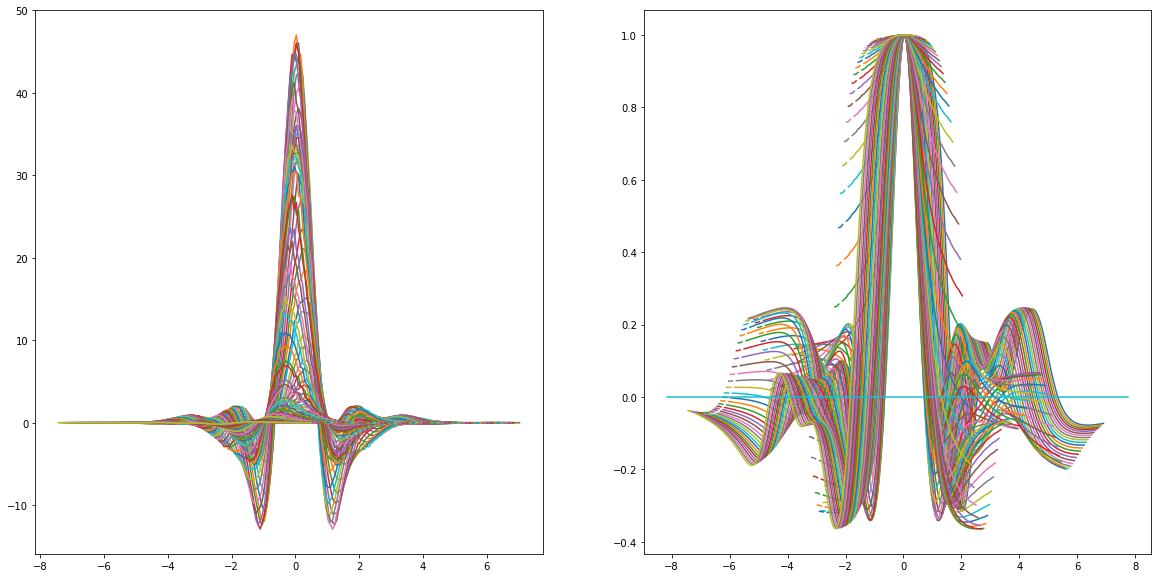

In [19]:
first_bin_index = 14
last_bin_index = hist_nbins - first_bin_index  +6

fig,ax = plt.subplots( 1, 2, figsize=(2*10,10))

axi = ax[0]

for bi in range(first_bin_index, last_bin_index+1) :
    
    xvals = hist_bin_centers + ( (hist_nbins)/2 - bi ) * hist_bin_width
    #print('  %3d : %s' % (bi, str(xvals)))
    axi.plot( xvals, hist_cov_mat[bi,:] )


    
axi = ax[1]

for bi in range(first_bin_index, last_bin_index+1) :
    
    xvals = hist_bin_centers + ( (hist_nbins)/2 - bi ) * hist_bin_width
    #print('  %3d : %s' % (bi, str(xvals)))
    axi.plot( xvals, hist_corr_mat[bi,:] )

   
axi.plot( axi.get_xlim(), [0,0])

plt.show




## Calculate a symmetrized, weighted average correlation

In [20]:
have = np.sum( boot_hist_content, axis=0 )
print(' have shape:  %s' % str(have.shape))
have = have / n_samples
have_integral = np.sum(have)
print(' Integral average:  %9.2f' % have_integral)

 have shape:  (120,)
 Integral average:   10004.82


In [21]:
nbins_for_ave = 8

first_bin_for_ave = int(hist_nbins/2) - int(nbins_for_ave/2)
last_bin_for_ave = first_bin_for_ave + nbins_for_ave - 1

hist_cov_shifted = np.zeros( shape=(hist_nbins, hist_nbins ) )
hist_corr_shifted = np.zeros( shape=(hist_nbins, hist_nbins ) )

for bi in range( first_bin_for_ave, last_bin_for_ave+1 ) :
    
    for bj in range( hist_nbins ) :
        
        sbi = -1*(bi - int(hist_nbins/2)) + bj
        
        if sbi < 0 : continue
        if sbi >= hist_nbins : continue
        
        #print('  bi = %3d,  bj = %3d,  sbi = %3d' % (bi, bj, sbi))
        
        hist_cov_shifted[ bi, sbi] = hist_cov_mat[bi,bj]
        
        hist_corr_shifted[ bi, sbi] = hist_corr_mat[bi,bj]
        
        
        
hist_width = hist_xhigh - hist_xlow
hist_bin_centers_shifted = np.linspace( -1*hist_width/2 + hist_bin_width/2, hist_width/2 - hist_bin_width/2, hist_nbins ) 

    
    

<function matplotlib.pyplot.show(close=None, block=None)>

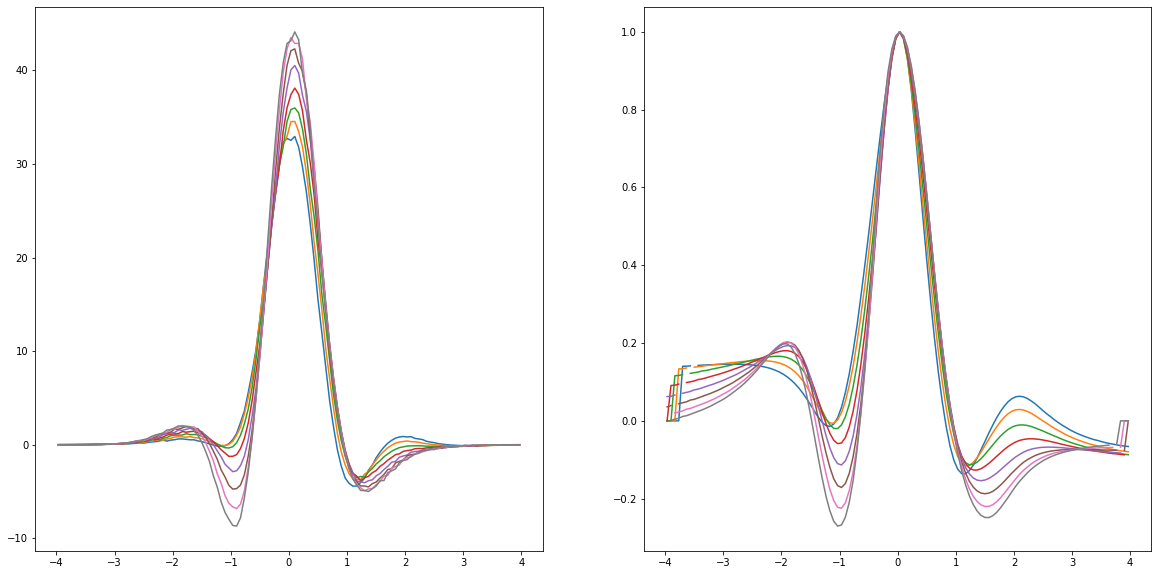

In [22]:
fig,ax = plt.subplots( 1, 2, figsize=(2*10,10))

axi = ax[0]

for bi in range( first_bin_for_ave, last_bin_for_ave+1 ) :
    axi.plot( hist_bin_centers_shifted, hist_cov_shifted[bi,:])

axi = ax[1]

for bi in range( first_bin_for_ave, last_bin_for_ave+1 ) :
    axi.plot( hist_bin_centers_shifted, hist_corr_shifted[bi,:])

    
plt.show

In [23]:

hist_corr_shifted_wsum = np.zeros( hist_nbins )

wsum = 0

for bi in range( first_bin_for_ave, last_bin_for_ave+1 ) :
    
    for i in range( hist_nbins ) :
        if np.isnan(hist_corr_shifted[bi,i])  : hist_corr_shifted[bi,i] = 0

    hist_corr_shifted_wsum += have[bi] * hist_corr_shifted[bi,:]
    
    wsum += have[bi]
    
    
hist_corr_shifted_ave = (1./wsum) * hist_corr_shifted_wsum
    

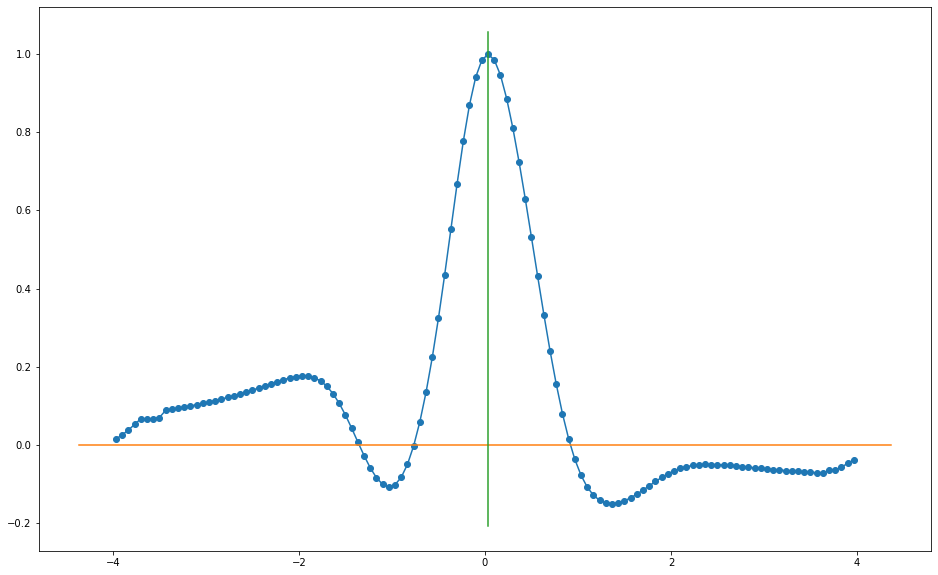

In [24]:
fig,ax = plt.subplots( 1, 1, figsize=(1*16,10))

axi = ax

plt.plot( hist_bin_centers_shifted, hist_corr_shifted_ave, marker='o' )
plt.plot( axi.get_xlim(), [0,0])
xcenter = hist_nbins/2
plt.plot( [hist_bin_width/2,hist_bin_width/2], axi.get_ylim())

In [25]:
for bi in range(hist_nbins) :
    print(' %3d :  %7.3f, %7.3f' % (bi, hist_bin_centers_shifted[bi], hist_corr_shifted_ave[bi]))

   0 :   -3.967,   0.015
   1 :   -3.900,   0.025
   2 :   -3.833,   0.038
   3 :   -3.767,   0.052
   4 :   -3.700,   0.066
   5 :   -3.633,   0.066
   6 :   -3.567,   0.067
   7 :   -3.500,   0.069
   8 :   -3.433,   0.088
   9 :   -3.367,   0.091
  10 :   -3.300,   0.093
  11 :   -3.233,   0.096
  12 :   -3.167,   0.099
  13 :   -3.100,   0.102
  14 :   -3.033,   0.106
  15 :   -2.967,   0.109
  16 :   -2.900,   0.113
  17 :   -2.833,   0.117
  18 :   -2.767,   0.121
  19 :   -2.700,   0.125
  20 :   -2.633,   0.130
  21 :   -2.567,   0.135
  22 :   -2.500,   0.140
  23 :   -2.433,   0.145
  24 :   -2.367,   0.150
  25 :   -2.300,   0.156
  26 :   -2.233,   0.161
  27 :   -2.167,   0.166
  28 :   -2.100,   0.171
  29 :   -2.033,   0.174
  30 :   -1.967,   0.176
  31 :   -1.900,   0.175
  32 :   -1.833,   0.171
  33 :   -1.767,   0.163
  34 :   -1.700,   0.150
  35 :   -1.633,   0.130
  36 :   -1.567,   0.106
  37 :   -1.500,   0.076
  38 :   -1.433,   0.042
  39 :   -1.367,   0.007
